# CELL 1 — Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# CELL 2 — Import Libraries

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import numpy as np
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


# CELL 3 —Loading model

In [4]:
LOAD_PATH = "/content/drive/MyDrive/final_weather_model_b3.pth"

checkpoint = torch.load(LOAD_PATH, map_location=device)

model = models.efficientnet_b3(weights=None)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 5)

model.load_state_dict(checkpoint['model_state_dict'])
class_names = checkpoint['class_names']

model.to(device)
model.eval()

print("Model loaded correctly")

Model loaded correctly


## Class names

In [5]:
print(class_names)

['cloudy', 'foggy', 'rainy', 'snowy', 'sunny']


# CELL 4 — Define Paths & Hyperparameters

In [6]:
DATASET_PATH = "/content/drive/MyDrive/data"

IMG_SIZE = 300
BATCH_SIZE = 16
VAL_SPLIT = 0.2

# CELL 5 — Data Transforms

In [7]:
train_transform = transforms.Compose([
    transforms.Resize((300, 300)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((300, 300)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# CELL 6 — Dataset Splitting

In [7]:
from torch.utils.data import Subset

# Load full dataset (no transform yet)
full_dataset = datasets.ImageFolder(DATASET_PATH)

# Split indices
val_size = int(len(full_dataset) * VAL_SPLIT)
train_size = len(full_dataset) - val_size

indices = torch.randperm(len(full_dataset)).tolist()

train_indices = indices[:train_size]
val_indices = indices[train_size:]

# Create separate datasets (🔥 FIX)
train_dataset = Subset(
    datasets.ImageFolder(DATASET_PATH, transform=train_transform),
    train_indices
)

val_dataset = Subset(
    datasets.ImageFolder(DATASET_PATH, transform=val_transform),
    val_indices
)

# DataLoaders (keep optimized)
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))

Train size: 14431
Val size: 3607


# CELL 7 — Data Loaders

In [8]:
from torchvision import datasets

dataset = datasets.ImageFolder( "/content/drive/MyDrive/data")

# CELL 8 — Class Weights

In [9]:
from sklearn.utils.class_weight import compute_class_weight

dataset = datasets.ImageFolder( "/content/drive/MyDrive/data")
targets = [label for _, label in dataset.samples]

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(targets),
    y=targets
)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

# soften weights
class_weights = class_weights * 0.7

print("Class Weights:", class_weights)

Class Weights: tensor([0.3768, 2.0042, 1.3105, 1.3468, 0.4025], device='cuda:0')


# Training

In [ ]:
EPOCHS = 8
best_val_acc = 0

for epoch in range(EPOCHS):

    model.train()
    train_correct = 0
    train_total = 0

    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    for images, labels in tqdm(train_loader):

        images = images.to(device, non_blocking=True)   # 🔥 faster GPU transfer
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        # 🔥 AMP safe usage
        with torch.amp.autocast(device_type="cuda", enabled=(device.type=="cuda")):
            outputs = model(images)
            loss = criterion(outputs, labels)

        # 🔥 scaler safe
        if device.type == "cuda":
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        _, predicted = torch.max(outputs, 1)

        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_acc = 100 * train_correct / train_total

    # 🔹 Validation
    model.eval()
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_acc = 100 * val_correct / val_total

    print("Train Acc:", train_acc)
    print("Val Acc:", val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "stage1_model.pth")
        print("Best model saved")


Epoch 1/8


100%|██████████| 902/902 [32:18<00:00,  2.15s/it]


Train Acc: 84.01358187235812
Val Acc: 90.9065705572498
Best model saved

Epoch 2/8


100%|██████████| 902/902 [03:17<00:00,  4.56it/s]


Train Acc: 89.02362968609243
Val Acc: 92.04324923759357
Best model saved

Epoch 3/8


...

Train Acc: 95.20476751437877
Val Acc: 92.20959245910728

Epoch 7/8


100%|██████████| 902/902 [03:17<00:00,  4.56it/s]


Train Acc: 95.34335804864527
Val Acc: 92.70862212364847

Epoch 8/8


100%|██████████| 902/902 [03:18<00:00,  4.55it/s]


Train Acc: 96.17490125424433
Val Acc: 92.93041308566676


# Unfreezing 30 layers

In [ ]:
for param in model.features[-30:].parameters():
    param.requires_grad = True

# Optimizer

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

# Fine tuning

In [ ]:
EPOCHS_FINE = 4

for epoch in range(EPOCHS_FINE):

    model.train()
    train_correct = 0
    train_total = 0

    print(f"\nFine Epoch {epoch+1}/{EPOCHS_FINE}")

    for images, labels in tqdm(train_loader):

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        with torch.amp.autocast(device_type="cuda", enabled=(device.type=="cuda")):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        _, predicted = torch.max(outputs, 1)

        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_acc = 100 * train_correct / train_total

    # Validation
    model.eval()
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_acc = 100 * val_correct / val_total

    print("Train Acc:", train_acc)
    print("Val Acc:", val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "final_model.pth")
        print("Final model saved")


Fine Epoch 1/4


100%|██████████| 902/902 [03:24<00:00,  4.41it/s]


Train Acc: 94.63654632388608
Val Acc: 93.4848904907125
Final model saved

Fine Epoch 2/4


100%|██████████| 902/902 [03:17<00:00,  4.56it/s]


Train Acc: 95.2394151479454
Val Acc: 93.54033823121708
Final model saved

Fine Epoch 3/4


100%|██████████| 902/902 [03:21<00:00,  4.48it/s]


Train Acc: 95.38493520892523
Val Acc: 93.51261436096479

Fine Epoch 4/4


100%|██████████| 902/902 [03:20<00:00,  4.49it/s]


Train Acc: 95.89772018571132
Val Acc: 93.51261436096479


# Saving model

In [ ]:


SAVE_PATH = "/content/drive/MyDrive/final_weather_model_b3.pth"

torch.save({
    'model_state_dict': model.state_dict(),
    'class_names': dataset.classes   # save class labels also
}, SAVE_PATH)

print("Model saved successfully!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model saved successfully!


Evaluation of classfication matrix and confusion matrix


Classification Report:

              precision    recall  f1-score   support

      cloudy       0.93      0.94      0.93      1336
       foggy       0.91      0.93      0.92       238
       rainy       0.92      0.93      0.93       413
       snowy       0.97      0.93      0.95       384
       sunny       0.94      0.93      0.94      1236

    accuracy                           0.94      3607
   macro avg       0.93      0.93      0.93      3607
weighted avg       0.94      0.94      0.94      3607



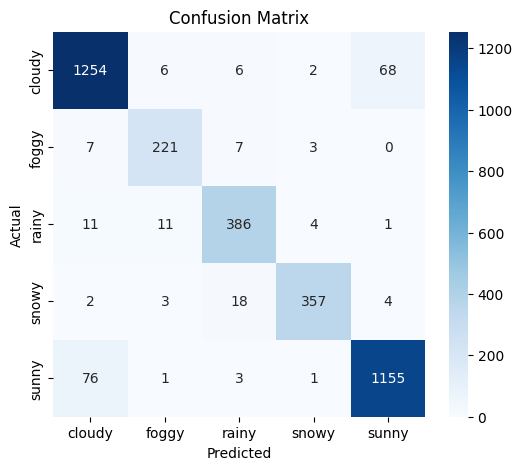

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Classification Report
print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds, target_names=dataset.classes))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=dataset.classes,
            yticklabels=dataset.classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Final Accuracy

In [ ]:
print("Final Training Accuracy:", train_acc)
print("Best Validation Accuracy:", best_val_acc)
print("Final Validation Accuracy (from predictions):", accuracy_score(all_labels, all_preds))

Final Training Accuracy: 95.89772018571132
Best Validation Accuracy: 93.54033823121708
Final Validation Accuracy (from predictions): 0.9351261436096479


# Testing

Saving cloud3.jpg to cloud3 (1).jpg


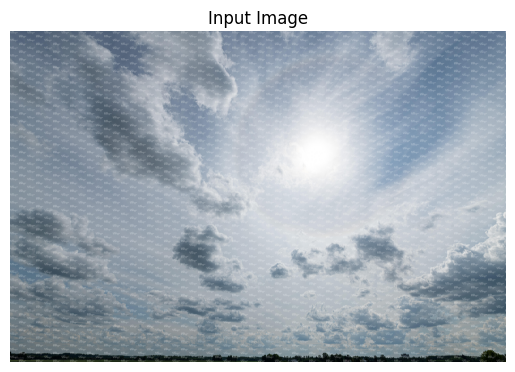


Top 2 Predictions:

1. cloudy → 97.63%
2. sunny → 2.16%


In [9]:
from google.colab import files
from PIL import Image
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Upload image
uploaded = files.upload()

for img_name in uploaded.keys():

    # Load image
    img = Image.open(img_name).convert('RGB')

    # Show image
    plt.imshow(img)
    plt.axis('off')
    plt.title("Input Image")
    plt.show()

    # Transform (IMPORTANT: must include normalization)
    img_tensor = val_transform(img).unsqueeze(0).to(device)

    # Prediction
    with torch.no_grad():
        outputs = model(img_tensor)
        probs = F.softmax(outputs, dim=1)

        top2_prob, top2_idx = torch.topk(probs, 2)

    print("\nTop 2 Predictions:\n")

    for i in range(2):
        class_name = class_names[top2_idx[0][i]]   # ✅ FIXED
        probability = top2_prob[0][i].item() * 100
        print(f"{i+1}. {class_name} → {probability:.2f}%")